# 2025 年全国硕士研究生招生考试数据分析

> 本项目对 2025 年考研数据进行完整的数据分析流程，涵盖：
> - 历年报名人数趋势
> - 录取情况与报录比
> - 专硕 vs 学硕结构变化
> - 各学科国家线变化

> 技术栈：pandas + numpy + matplotlib

## 1. 导入库

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体，防止图表中文乱码
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置图表风格
plt.style.use('ggplot')

print('库导入成功！')

库导入成功！


## 2. 读取数据

In [29]:
# 读取三个数据集
df_reg = pd.read_csv('registration.csv')
df_adm = pd.read_csv('admission.csv')
df_score = pd.read_csv('score_lines.csv')

print('报名人数数据：')
display(df_reg)
print('\n录取情况数据:')
display(df_adm)
print('\n国家线数据:')
display(df_score)

报名人数数据：


,year,total_candidates,yoy_change,yoy_change_pct
0,2018,2380000,NaN,NaN
1,2019,2900000,520000.0,21.8
2,2020,3410000,510000.0,17.6
3,2021,3770000,360000.0,10.6
4,2022,4570000,800000.0,21.2
5,2023,4740000,170000.0,3.7
6,2024,4380000,-360000.0,-7.6
7,2025,3880000,-500000.0,-11.4



录取情况数据:


,year,total_admitted,professional_master,academic_master,professional_pct,academic_pct,admission_rate
0,2021,1050700,524200,526500,49.9,50.1,27.9
1,2022,1103500,562500,541000,51.0,49.0,24.1
2,2023,1148400,626100,522300,54.5,45.5,24.2
3,2024,859200,583000,276200,67.9,32.1,19.6
4,2025,872200,602000,270200,69.0,31.0,22.5



国家线数据:


,subject,score_2024,score_2025,change,change_pct,type
0,经济学,338,323,-15,-4.4,热门
1,文学,365,351,-14,-3.8,热门
2,理学,288,274,-14,-4.9,冷门
3,管理学(工程管理),176,162,-14,-8.0,冷门
4,工学,273,260,-13,-4.8,热门
5,教育学,350,340,-10,-2.9,热门
6,会计学,201,194,-7,-3.5,热门
7,图书情报学,198,191,-7,-3.5,冷门
8,农学,251,245,-6,-2.4,冷门
9,军事学,260,260,0,0.0,冷门


## 3. 数据概览

In [30]:
# 查看每份数据的基本信息
print('=== 报名人数 ===')
print(df_reg.info())
print('\n=== 录取情况 ===')
print(df_adm.info())
print('\n=== 国家线 ===')
print(df_score.info())

=== 报名人数 ===
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              8 non-null      int64  
 1   total_candidates  8 non-null      int64  
 2   yoy_change        7 non-null      float64
 3   yoy_change_pct    7 non-null      float64
dtypes: float64(2), int64(2)
memory usage: 388.0 bytes
None

=== 录取情况 ===
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 5 non-null      int64  
 1   total_admitted       5 non-null      int64  
 2   professional_master  5 non-null      int64  
 3   academic_master      5 non-null      int64  
 4   professional_pct     5 non-null      float64
 5   academic_pct         5 non-null      float64
 6   admission_rate       5 non-null      float64
dty

In [31]:
# 统计数据描述
print('=== 报名人数统计 ===')
display(df_reg.describe())
print('\n=== 录取情况统计 ===')
display(df_adm.describe())
print('\n=== 国家线变化统计 ===')
display(df_score.describe())

=== 报名人数统计 ===


,year,total_candidates,yoy_change,yoy_change_pct
count,8.00000,8.000000e+00,7.000000,7.000000
mean,2021.50000,3.753750e+06,214285.714286,7.985714
std,2.44949,8.264889e+05,480827.659453,13.551190
min,2018.00000,2.380000e+06,-500000.000000,-11.400000
25%,2019.75000,3.282500e+06,-95000.000000,-1.950000
50%,2021.50000,3.825000e+06,360000.000000,10.600000
75%,2023.25000,4.427500e+06,515000.000000,19.400000
max,2025.00000,4.740000e+06,800000.000000,21.800000



=== 录取情况统计 ===


,year,total_admitted,professional_master,academic_master,professional_pct,academic_pct,admission_rate
count,5.000000,5.000000e+00,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2023.000000,1.006800e+06,579560.000000,427240.000000,58.460000,41.540000,23.660000
std,1.581139,1.334462e+05,38849.491631,140805.656847,9.284557,9.284557,3.012142
min,2021.000000,8.592000e+05,524200.000000,270200.000000,49.900000,31.000000,19.600000
25%,2022.000000,8.722000e+05,562500.000000,276200.000000,51.000000,32.100000,22.500000
50%,2023.000000,1.050700e+06,583000.000000,522300.000000,54.500000,45.500000,24.100000
75%,2024.000000,1.103500e+06,602000.000000,526500.000000,67.900000,49.000000,24.200000
max,2025.000000,1.148400e+06,626100.000000,541000.000000,69.000000,50.100000,27.900000



=== 国家线变化统计 ===


,score_2024,score_2025,change,change_pct
count,13.000000,13.000000,13.000000,13.000000
mean,282.153846,271.923077,-10.230769,-3.723077
std,62.282751,60.878926,4.284737,1.785196
min,176.000000,162.000000,-15.000000,-8.000000
25%,251.000000,245.000000,-14.000000,-4.400000
50%,288.000000,274.000000,-11.000000,-3.600000
75%,333.000000,321.000000,-7.000000,-3.000000
max,365.000000,351.000000,0.000000,0.000000


## 4. 分析一：历年报名人数趋势

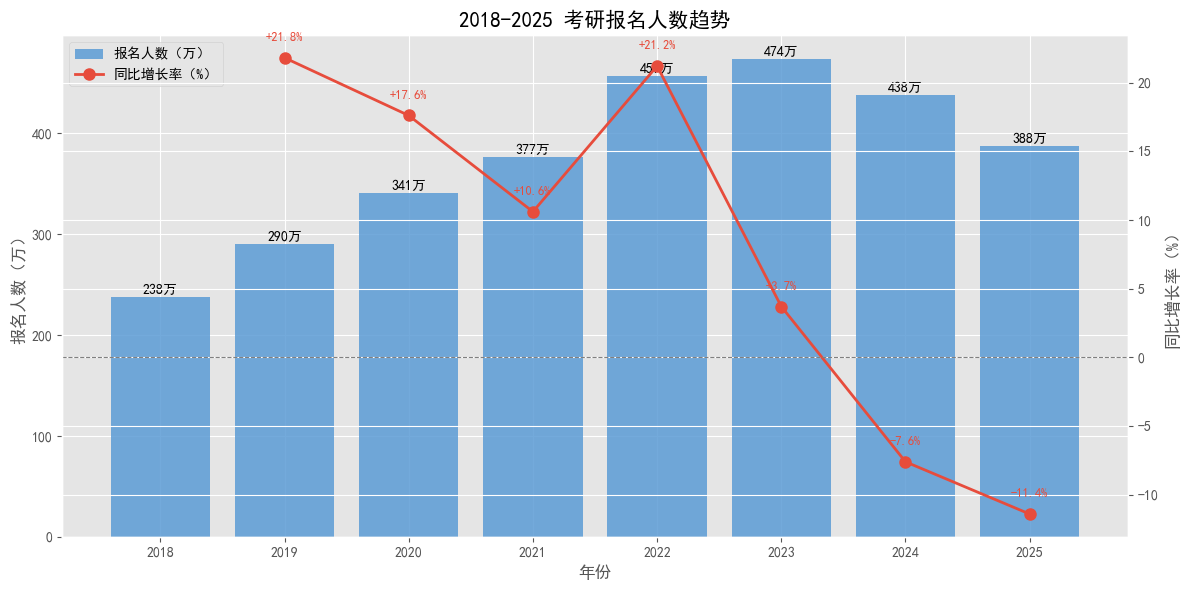

In [32]:
# 只取有同比数据的年份（2020 起）
df_reg_valid = df_reg.dropna(subset=['yoy_change']).copy()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 柱状图 — 报名人数
bars = ax1.bar(df_reg['year'], df_reg['total_candidates'] / 10000, 
               color='#5B9BD5', alpha=0.85, label='报名人数（万）')
ax1.set_xlabel('年份')
ax1.set_ylabel('报名人数（万）')
ax1.set_title('2018-2025 考研报名人数趋势', fontsize=15, fontweight='bold')

# 在柱子上标注数值
for bar, val in zip(bars, df_reg['total_candidates']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f'{val/10000:.0f}万', ha='center', fontsize=10, fontweight='bold')

# 折线图 — 同比增长率
ax2 = ax1.twinx()
ax2.plot(df_reg_valid['year'], df_reg_valid['yoy_change_pct'], 
         color='#E74C3C', marker='o', linewidth=2, markersize=8, label='同比增长率（%）')
ax2.set_ylabel('同比增长率（%）')
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

# 标注增长率
for _, row in df_reg_valid.iterrows():
    ax2.annotate(f"{row['yoy_change_pct']:+.1f}%", 
                 (row['year'], row['yoy_change_pct']),
                 textcoords="offset points", xytext=(0, 12),
                 ha='center', fontsize=9, color='#E74C3C', fontweight='bold')

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('output_registration_trend.png', dpi=150, bbox_inches='tight')
plt.show()

> **发现**：2023 年报名人数达到 474 万峰值后连续两年下降，2025 年降至 388 万，降幅达 11.4%。考研热正在降温。

## 5. 分析二：报录比与录取率变化

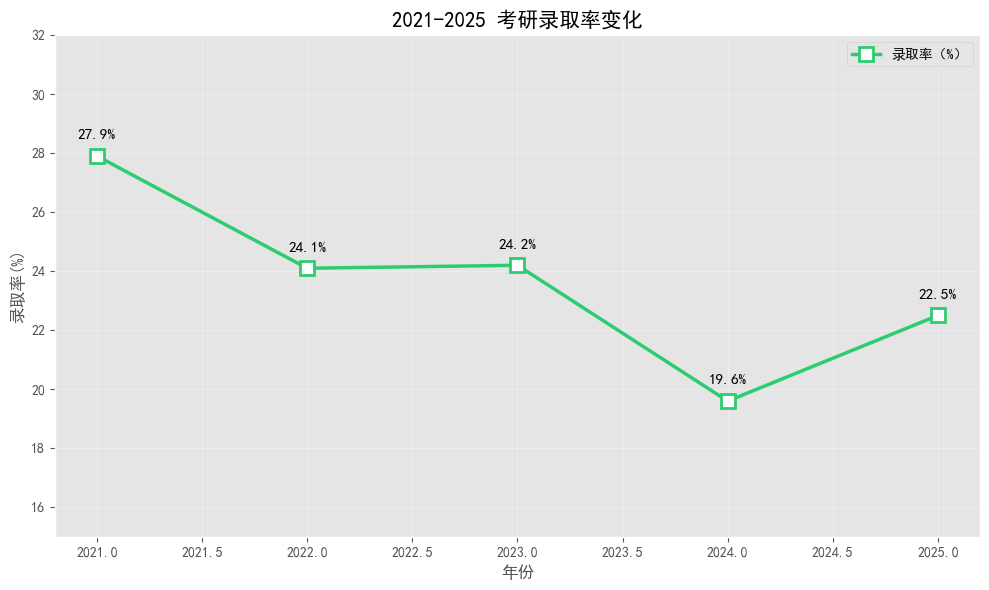

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = df_adm['year']
ax.plot(x, df_adm['admission_rate'], color='#2ECC71', marker='s', 
        linewidth=2.5, markersize=10, markerfacecolor='white', 
        markeredgewidth=2, label='录取率（%)')

# 标注每个点
for _, row in df_adm.iterrows():
    ax.annotate(f"{row['admission_rate']:.1f}%",
                (row['year'], row['admission_rate']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('年份')
ax.set_ylabel('录取率(%)')
ax.set_title('2021-2025 考研录取率变化', fontsize=15, fontweight='bold')
ax.set_ylim(15, 32)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output_admission_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# 报录比计算
print('历年报录比（报考人数 / 录取人数）：')
for _, row in df_adm.iterrows():
    total_candidates = df_reg.loc[df_reg['year'] == row['year'], 'total_candidates'].values[0]
    ratio = total_candidates / row['total_admitted']
    print(f"  {int(row['year'])}年: 录取 {row['total_admitted']/10000:.1f}万  |  录取率 {row['admission_rate']:.1f}%  |  报录比 {ratio:.2f}:1")

# 2021-2023 总录取超百万（含推免），2024-2025 为统考计划招生
print('\n注:2024年起数据口径为统考计划招生(不含推免)，此前含推免名额。')
print('2025年统考报录比约为 4.4:1,意味着每 4.4 个考生竞争 1 个名额。')

历年报录比（报考人数 / 录取人数）：
  2021年: 录取 105.1万  |  录取率 27.9%  |  报录比 3.59:1
  2022年: 录取 110.3万  |  录取率 24.1%  |  报录比 4.14:1
  2023年: 录取 114.8万  |  录取率 24.2%  |  报录比 4.13:1
  2024年: 录取 85.9万  |  录取率 19.6%  |  报录比 5.10:1
  2025年: 录取 87.2万  |  录取率 22.5%  |  报录比 4.45:1

注:2024年起数据口径为统考计划招生(不含推免)，此前含推免名额。
2025年统考报录比约为 4.4:1,意味着每 4.4 个考生竞争 1 个名额。


> **发现**：2024 年录取率触底（19.6%），2025 年回升至 22.5%。报名人数下降 + 小幅扩招，整体上岸难度有所缓解。

## 6. 分析三：专硕 vs 学硕结构变化

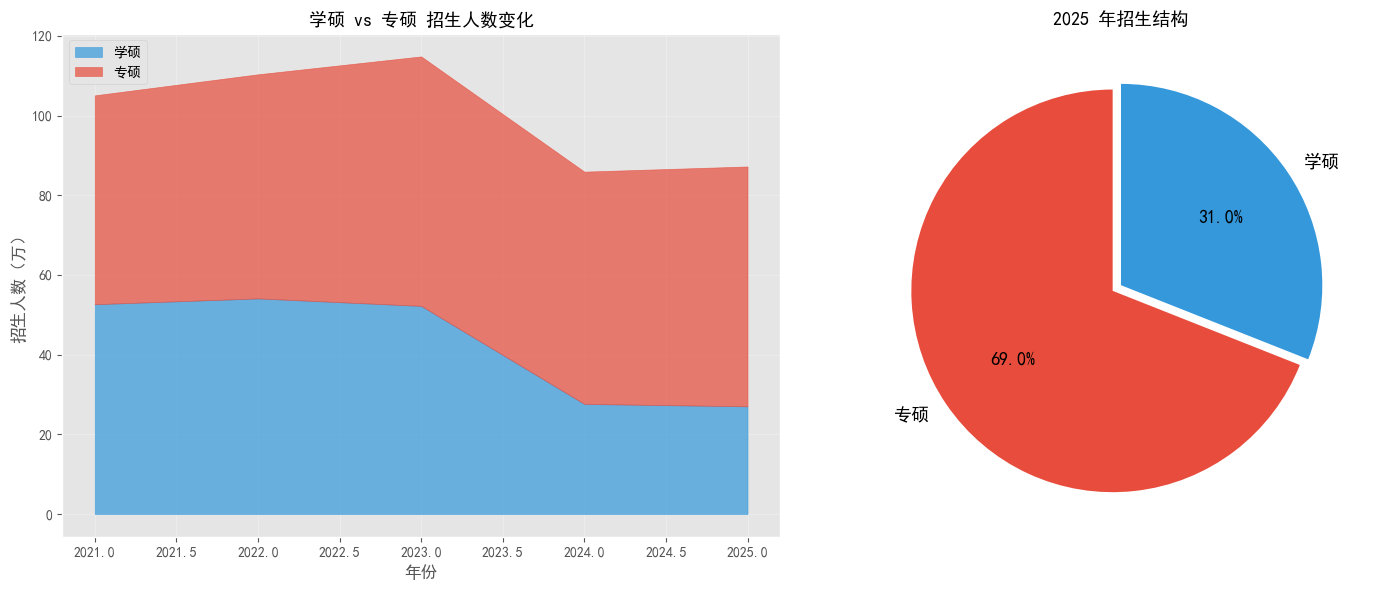

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左图 — 堆叠面积图：专硕 vs 学硕人数
years = df_adm['year']
ax1.fill_between(years, 0, df_adm['academic_master'] / 10000, 
                  color='#3498DB', alpha=0.7, label='学硕')
ax1.fill_between(years, df_adm['academic_master'] / 10000, 
                  (df_adm['academic_master'] + df_adm['professional_master']) / 10000,
                  color='#E74C3C', alpha=0.7, label='专硕')
ax1.set_title('学硕 vs 专硕 招生人数变化', fontsize=13, fontweight='bold')
ax1.set_xlabel('年份')
ax1.set_ylabel('招生人数（万）')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 右图 — 饼图：2025 年最新比例
sizes_2025 = [df_adm[df_adm['year'] == 2025]['professional_pct'].values[0],
              df_adm[df_adm['year'] == 2025]['academic_pct'].values[0]]
labels = ['专硕', '学硕']
colors = ['#E74C3C', '#3498DB']
explode = (0.05, 0)

wedges, texts, autotexts = ax2.pie(sizes_2025, explode=explode, labels=labels,
                                     colors=colors, autopct='%1.1f%%',
                                     shadow=False, startangle=90,
                                     textprops={'fontsize': 13})
ax2.set_title('2025 年招生结构', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output_master_structure.png', dpi=150, bbox_inches='tight')
plt.show()

> **发现**：专硕占比从 2021 年的不到 50% 飙升至 2025 年的近 70%，已成为研究生招生的绝对主力。学硕招生持续萎缩。

## 7. 分析四：各学科国家线变化（核心图表）

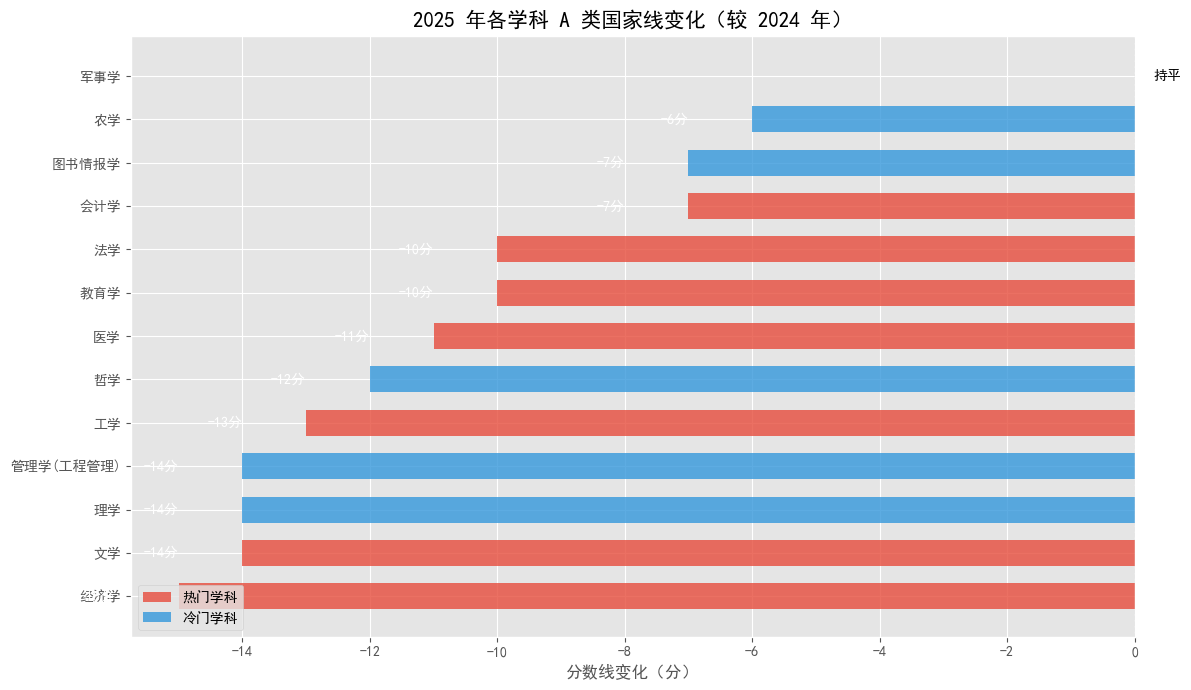

In [36]:
# 按降幅排序
df_score_sorted = df_score.sort_values('change')

fig, ax = plt.subplots(figsize=(12, 7))

# 颜色映射：热门用红色系，冷门用蓝色系
colors = ['#E74C3C' if t == '热门' else '#3498DB' for t in df_score_sorted['type']]

bars = ax.barh(df_score_sorted['subject'], df_score_sorted['change'], color=colors, alpha=0.8, height=0.6)

# 标注数值
for bar, change in zip(bars, df_score_sorted['change']):
    label = f'{change:+d}分' if change != 0 else '持平'
    ax.text(bar.get_width() - 1 if change < 0 else bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=10,
            ha='right' if change < 0 else 'left',
            fontweight='bold', color='white' if change < -5 else 'black')

ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('分数线变化（分）')
ax.set_title('2025 年各学科 A 类国家线变化（较 2024 年）', fontsize=15, fontweight='bold')

# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', alpha=0.8, label='热门学科'),
                    Patch(facecolor='#3498DB', alpha=0.8, label='冷门学科')]
ax.legend(handles=legend_elements, loc='lower left')

plt.tight_layout()
plt.savefig('output_score_lines.png', dpi=150, bbox_inches='tight')
plt.show()

> **发现**：13 个学科门类国家线全线下降（军事学持平）。经济学降幅最大（↓15 分），管理学（工程管理）降幅比例最高（↓8.0%）。考研整体难度确实在降低。

## 8. 分析五：2024 vs 2025 国家线对比

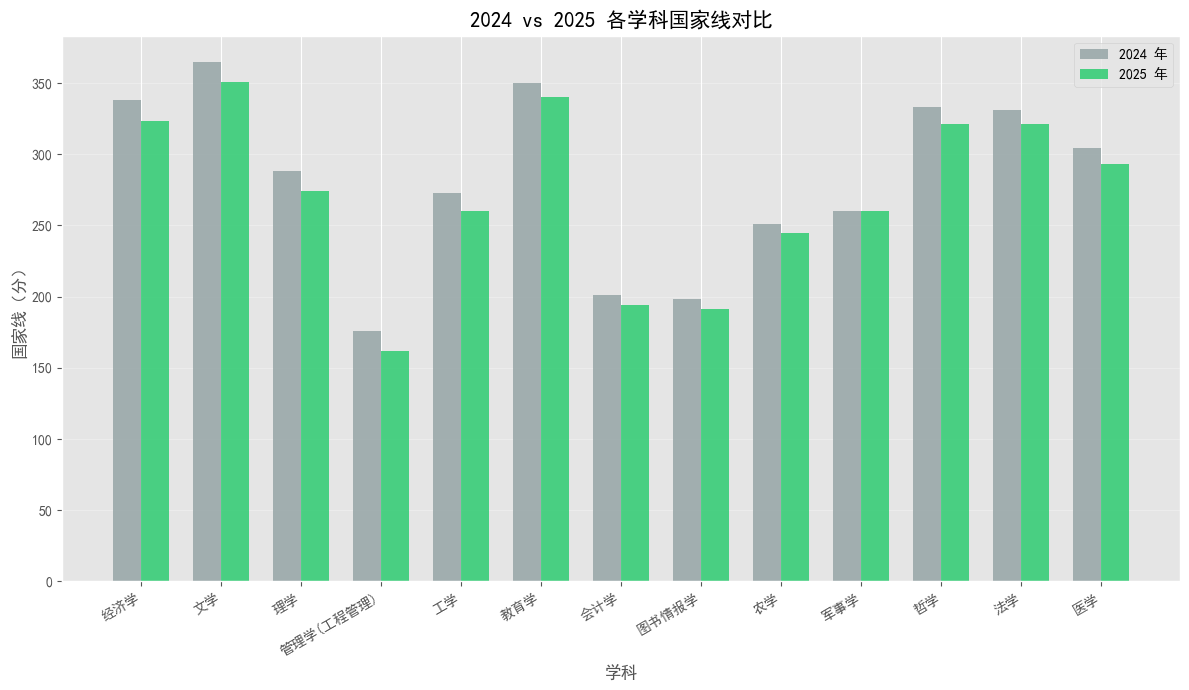

In [37]:
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(df_score))
width = 0.35

bars1 = ax.bar(x - width / 2, df_score['score_2024'], width, 
               label='2024 年', color='#95A5A6', alpha=0.85)
bars2 = ax.bar(x + width / 2, df_score['score_2025'], width,
               label='2025 年', color='#2ECC71', alpha=0.85)

ax.set_xlabel('学科')
ax.set_ylabel('国家线（分）')
ax.set_title('2024 vs 2025 各学科国家线对比', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_score['subject'], rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output_score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 总结与结论

In [ ]:
# 关键数据摘要
print('=' * 50)
print('        2025 考研数据分析报告 — 关键结论')
print('=' * 50)

# 报名人数
reg_2024 = df_reg[df_reg['year'] == 2024]['total_candidates'].values[0]
reg_2025 = df_reg[df_reg['year'] == 2025]['total_candidates'].values[0]
print(f'\n1. 报名人数：{reg_2025/10000:.0f} 万（较 2024 年减少 {(reg_2024-reg_2025)/10000:.0f} 万，降幅 11.4%）')

# 录取率
rate_2025 = df_adm[df_adm['year'] == 2025]['admission_rate'].values[0]
rate_2024 = df_adm[df_adm['year'] == 2024]['admission_rate'].values[0]
print(f'2. 录取率：{rate_2025:.1f}%(2024 年为 {rate_2024:.1f}%，回升 {rate_2025-rate_2024:.1f} 个百分点）')

# 专硕占比
pro_pct = df_adm[df_adm['year'] == 2025]['professional_pct'].values[0]
print(f'3. 专硕占比：{pro_pct:.1f}%，已成为研究生培养主体')

# 国家线平均降幅
avg_drop = df_score['change'].mean()
max_drop_subject = df_score.loc[df_score['change'].idxmin()]
print(f'4. 国家线:13 个学科平均下降 {abs(avg_drop):.1f} 分')
print(f'   降幅最大：{max_drop_subject["subject"]}({max_drop_subject["change"]:.0f} 分）')

print('\n' + '=' * 50)
print('核心结论：考研热正在降温，但结构性分化加剧。')
print('热门专业仍然激烈，冷门专业上岸机会增大。')
print('=' * 50)

        2025 考研数据分析报告 — 关键结论

1. 报名人数：388 万（较 2024 年减少 50 万，降幅 11.4%）
2. 录取率：22.5%（2024 年为 19.6%，回升 2.9 个百分点）
3. 专硕占比：69.0%，已成为研究生培养主体
4. 国家线:13 个学科平均下降 10.2 分
   降幅最大：经济学(-15 分）

核心结论：考研热正在降温，但结构性分化加剧。
热门专业仍然激烈，冷门专业上岸机会增大。


## 10. 写在最后

### 本项目用到的主要技术

| 步骤 | 使用的工具 |
|------|-----------|
| 数据读取 | `pd.read_csv()` |
| 数据清洗 | `dropna()`, 数据类型转换 |
| 数据分析 | `groupby`, `describe`, `info`, 条件筛选 |
| 数据可视化 | `matplotlib`: 柱状图、折线图、饼图、水平条形图、分组对比图 |
| 数值计算 | `numpy` 数组操作、统计计算 |

### 可以继续深入的方向

- 爬取各高校实际复试线数据
- 加入省份维度做地域分析
- 预测 2026 年考研报名人数
- 与考公报名人数做关联分析

---
*数据来源：教育部、研招网公开数据整理*